<style>
:root { --navy:#123047; --blue:#167d9a; --aqua:#47b8a6; --sand:#f4efe6; --ink:#19313b; --muted:#5f7480; }
.lab-hero { padding:32px 38px; border-radius:22px; color:white; margin:8px 0 22px;
  background:linear-gradient(125deg,#102c44 0%,#126e83 58%,#4db49f 100%);
  box-shadow:0 15px 35px rgba(16,44,68,.18); }
.lab-kicker { text-transform:uppercase; letter-spacing:.16em; font-size:.78rem; opacity:.82; font-weight:700; }
.lab-hero h1 { color:white !important; margin:.45rem 0 .55rem; font-size:2.35rem; line-height:1.08; }
.lab-hero p { max-width:850px; font-size:1.04rem; line-height:1.6; margin:0; opacity:.94; }
.lab-section { border-left:5px solid var(--aqua); padding:3px 0 3px 18px; margin:30px 0 14px; }
.lab-section h2 { color:var(--navy) !important; margin:0 0 4px; }
.lab-section p { color:var(--muted); margin:0; }
.metric-grid { display:grid; grid-template-columns:repeat(auto-fit,minmax(170px,1fr)); gap:12px; margin:14px 0 22px; }
.metric { border:1px solid #d8e5e7; border-radius:15px; padding:16px 18px; background:#fbfdfd; }
.metric .value { font-size:1.65rem; font-weight:800; color:var(--blue); }
.metric .label { color:var(--muted); font-size:.86rem; margin-top:3px; }
.callout { border-radius:14px; padding:15px 18px; margin:14px 0; background:#eef8f6; border:1px solid #c8e8e1; color:var(--ink); }
.warning { background:#fff7e8; border-color:#f1d39b; }
.formula { font-family:Cambria,serif; background:#f4f7f8; border-radius:12px; padding:12px 16px; text-align:center; }
.tag { display:inline-block; padding:4px 9px; border-radius:999px; margin:2px; background:#dff2ef; color:#176d68; font-size:.78rem; font-weight:700; }
table { font-size:.91rem; }
</style>

<div class="lab-hero">
  <div class="lab-kicker">CC3084 · Data Science · Laboratorio 4</div>
  <h1>Observando los lagos desde el espacio</h1>
  <p>Análisis geoespacial y temporal de cianobacterias en los lagos de Atitlán y Amatitlán mediante imágenes Sentinel‑2.</p>
</div>

<div class="lab-section"><h2>1. Propósito del avance</h2><p>De las instrucciones a un flujo verificable y reutilizable.</p></div>

Este avance cubre las bases de los ejercicios 1–4: conexión con Copernicus, definición de las áreas y fechas oficiales, selección mínima de bandas, construcción de índices y preparación del análisis temporal. No se interpretan resultados inexistentes: las conclusiones se completarán únicamente después de validar las descargas.

<div class="callout"><strong>Delimitación de los lagos.</strong> La guía permite usar «las coordenadas o el geojson provisto». La consulta a Copernicus se limita con las cajas envolventes publicadas en la guía y el recorte fino del espejo de agua se hace con los contornos de OpenStreetMap (relaciones 5781818 y 11018382, licencia ODbL), una fuente pública y reproducible. Sobre ese recorte se aplica una máscara dinámica que conserva píxeles sin nube con NDWI ≥ 0.</div>

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

from lab4.config import AREAS, RAW_DIR, FIGURES_DIR, TABLES_DIR, ensure_output_directories, load_observations
from lab4.analysis import CYANO_HIGH_THRESHOLD, read_index_raster, summarize_index_raster
from lab4.copernicus import build_lake_timeseries_cube, connect_cdse

ensure_output_directories()
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5.5), "figure.dpi": 120,
    "axes.titleweight": "bold", "axes.titlesize": 14,
    "axes.labelcolor": "#19313b", "text.color": "#19313b",
})
PALETTE = {"atitlan": "#167d9a", "amatitlan": "#d5793d"}

display(HTML("<div class='callout'><strong>Entorno listo.</strong> Configuración, funciones y rutas del proyecto fueron cargadas.</div>"))

<div class="lab-section"><h2>2. Diseño del estudio</h2><p>Dos lagos, 22 fechas y una misma metodología.</p></div>

In [2]:
observaciones = load_observations()
cards = []
for lake, group in observaciones.groupby("lago"):
    cards.append(f"<div class='metric'><div class='value'>{len(group)}</div><div class='label'>fechas · {AREAS[lake].name}</div></div>")
cards.extend([
    "<div class='metric'><div class='value'>20 m</div><div class='label'>resolución común</div></div>",
    "<div class='metric'><div class='value'>3</div><div class='label'>productos: NDVI, NDWI y CYA</div></div>",
])
display(HTML("<div class='metric-grid'>" + "".join(cards) + "</div>"))
display(observaciones.style.hide(axis="index").format({"nubosidad_pct": "{:.2f}"}))

lago,fecha,nubosidad_pct,satelite,cobertura_valida_pct,nota
amatitlan,2025-01-28 00:00:00,0.06,Sentinel-2B,nan,nan
amatitlan,2025-04-15 00:00:00,0.09,Sentinel-2A,nan,nan
amatitlan,2025-04-28 00:00:00,1.03,Sentinel-2B,nan,nan
amatitlan,2025-11-24 00:00:00,0.50,Sentinel-2B,nan,nan
amatitlan,2026-01-08 00:00:00,0.77,Sentinel-2C,nan,nan
amatitlan,2026-02-02 00:00:00,0.39,Sentinel-2B,nan,nan
amatitlan,2026-02-07 00:00:00,0.02,Sentinel-2C,57.100000,Cobertura válida parcial según la guía
amatitlan,2026-03-29 00:00:00,0.01,Sentinel-2C,nan,nan
amatitlan,2026-04-13 00:00:00,0.09,Sentinel-2B,nan,nan
amatitlan,2026-04-28 00:00:00,4.96,Sentinel-2C,nan,nan


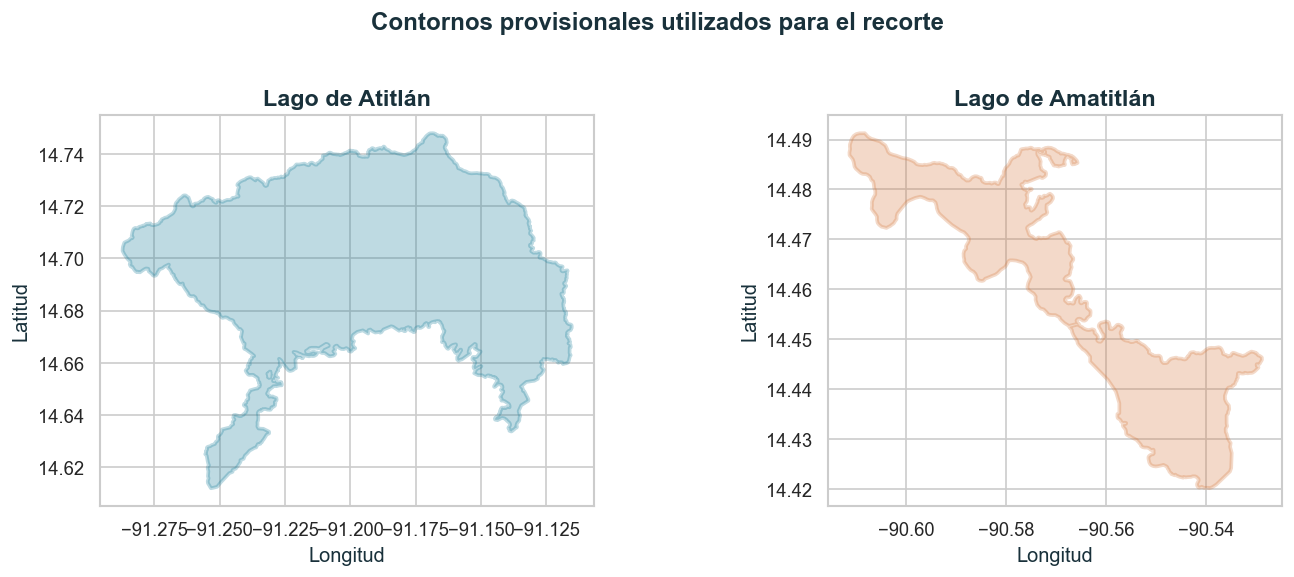

In [3]:
boundaries = gpd.read_file(ROOT / "config" / "lake_boundaries_osm.geojson")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
for ax, (key, area) in zip(axes, AREAS.items()):
    shape = boundaries.query("id == @key")
    shape.plot(ax=ax, facecolor=PALETTE[key], alpha=.28,
               edgecolor=PALETTE[key], linewidth=2.2)
    ax.set(xlabel="Longitud", ylabel="Latitud", title=area.name)
    ax.set_aspect("equal", adjustable="box")
fig.suptitle("Contornos provisionales utilizados para el recorte", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

<div class="lab-section"><h2>3. Variables espectrales</h2><p>Se descargan productos derivados, no escenas completas.</p></div>

<span class="tag">B02 · azul</span><span class="tag">B03 · verde</span><span class="tag">B04 · rojo</span><span class="tag">B08 · infrarrojo cercano</span><span class="tag">SCL · calidad</span>

<div class="formula"><strong>NDVI</strong> = (B08 − B04) / (B08 + B04) &nbsp;&nbsp; · &nbsp;&nbsp; <strong>NDWI</strong> = (B03 − B08) / (B03 + B08)</div>

El proxy de cianobacteria reproduce el modelo empírico de **Se2WaQ** para Sentinel‑2 L2A:

<div class="formula"><strong>CYA</strong> = 115530.31 × ((B03 × B04) / B02)<sup>2.38</sup></div>

Las bandas se convierten primero a reflectancia mediante el factor 0.0001 informado por la colección. CYA se expresa como estimación de 10³ células/ml y no sustituye muestreos de laboratorio.

<div class="lab-section"><h2>4. Conexión y gráfica de procesamiento</h2><p>La autenticación se realiza con código de dispositivo; ninguna contraseña queda en el notebook.</p></div>

La siguiente celda solo construye y valida el flujo. Para descargar, se utiliza `python scripts/download_cdse.py --lake all --submit` desde una terminal. Así evitamos relanzar trabajos costosos al ejecutar todo el notebook.

In [4]:
connection = connect_cdse()
fechas_amatitlan = (observaciones.query("lago == 'amatitlan'")["fecha"]
                    .dt.date.astype(str).tolist())
cube_demo = build_lake_timeseries_cube(connection, "amatitlan", fechas_amatitlan[:1], resolution=20)
errores = connection.validate_process_graph(cube_demo)

status = "Gráfica válida" if not errores else "Revisar gráfica"
css = "callout" if not errores else "callout warning"
display(HTML(f"<div class='{css}'><strong>{status}.</strong> La prueba contiene {len(cube_demo.flat_graph())} nodos y las bandas {cube_demo.metadata.band_names}.</div>"))
errores

[]

<div class="lab-section"><h2>5. Control de calidad</h2><p>Una ausencia no se convierte en un cero.</p></div>

Se excluyen SCL 0, 1, 3, 8, 9, 10 y 11: sin datos, píxeles saturados, sombra de nube, nubes de probabilidad media/alta, cirros y nieve. Después se conserva agua provisional con NDWI ≥ 0 y se exigen reflectancias positivas en las cuatro bandas. Los valores excluidos permanecen como **NoData**, evitando índices fuera de su dominio y promedios sesgados hacia cero.

La fecha 2026‑02‑07 de Amatitlán se analizará con cautela porque la guía reporta solo 57.1 % de cobertura válida.

<div class="lab-section"><h2>6. Inventario de descargas</h2><p>El bloque se actualiza automáticamente cuando existan GeoTIFF.</p></div>

In [5]:
tifs = sorted(RAW_DIR.glob("**/*.tif"))
inventory = pd.DataFrame({
    "archivo": [p.name for p in tifs],
    "lago": [p.parent.name for p in tifs],
    "tamano_mb": [p.stat().st_size / 1024**2 for p in tifs],
})
if inventory.empty:
    display(HTML("<div class='callout warning'><strong>Sin rásteres todavía.</strong> Ejecute el descargador autenticado y vuelva a esta sección.</div>"))
else:
    display(inventory.style.hide(axis="index").format({"tamano_mb": "{:.2f}"}))

archivo,lago,tamano_mb
openEO_2025-01-28Z.tif,amatitlan,0.51
openEO_2025-04-15Z.tif,amatitlan,0.57
openEO_2025-04-28Z.tif,amatitlan,0.56
openEO_2025-11-24Z.tif,amatitlan,0.51
openEO_2026-01-08Z.tif,amatitlan,0.51
openEO_2026-02-02Z.tif,amatitlan,0.52
openEO_2026-02-07Z.tif,amatitlan,0.48
openEO_2026-03-29Z.tif,amatitlan,0.56
openEO_2026-04-13Z.tif,amatitlan,0.58
openEO_2026-04-28Z.tif,amatitlan,0.46


<div class="lab-section"><h2>7. Resultados temporales preliminares</h2><p>Promedio, distribución y extensión alta por lago y fecha.</p></div>

El umbral inicial de CYA alta es **40 × 10³ células/ml**, tomado como corte exploratorio de la escala de Se2WaQ. Debe reportarse como decisión analítica y someterse a sensibilidad; no es un límite sanitario validado para Guatemala.

Para evitar que cocientes inestables causados por reflectancia azul muy pequeña dominen la media, los resúmenes utilizan la escala publicada de Se2WaQ entre 0 y 100. El GeoTIFF crudo se conserva sin truncar para auditoría.

In [6]:
# Los nombres de los activos de openEO incluyen la fecha ISO. Este bloque resume
# automáticamente cada GeoTIFF una vez terminadas las descargas.
import re

summaries = []
for path in tifs:
    match = re.search(r"20\d{2}-\d{2}-\d{2}", path.name)
    if match:
        summaries.append(summarize_index_raster(
            path, lake=path.parent.name, date=match.group(0),
            high_threshold=CYANO_HIGH_THRESHOLD,
        ))

stats = pd.concat(summaries, ignore_index=True) if summaries else pd.DataFrame()
if stats.empty:
    display(HTML("<div class='callout'>La tabla temporal se generará cuando existan activos descargados.</div>"))
else:
    stats.to_csv(TABLES_DIR / "estadisticas_indices.csv", index=False)
    display(stats.head().style.hide(axis="index"))

lago,fecha,indice,n_pixeles,media,mediana,desviacion,p90,minimo,maximo,porcentaje_alto,umbral_alto,porcentaje_saturado_100,maximo_crudo
amatitlan,2025-01-28,NDVI,35059,-0.370824,-0.343750,0.205518,-0.143860,-0.982759,0.446809,nan,nan,nan,nan
amatitlan,2025-01-28,NDWI,35059,0.591818,0.582418,0.159108,0.806452,0.001431,0.990991,nan,nan,nan,nan
amatitlan,2025-01-28,CYA,35059,7.568930,6.255226,5.688857,13.003511,0.213516,100.000000,0.453521,40.000000,0.019966,742.422791
amatitlan,2025-04-15,NDVI,36296,-0.094055,-0.105869,0.096285,0.024417,-0.975309,0.360134,nan,nan,nan,nan
amatitlan,2025-04-15,NDWI,36296,0.285883,0.289301,0.095048,0.395785,0.001353,0.988270,nan,nan,nan,nan


In [7]:
if not stats.empty:
    cya = stats.query("indice == 'CYA'").copy()
    cya["fecha"] = pd.to_datetime(cya["fecha"])
    display(cya[["lago", "fecha", "media", "mediana", "p90", "porcentaje_alto"]]
            .style.hide(axis="index").format({"media":"{:.2f}", "mediana":"{:.2f}",
                                               "p90":"{:.2f}", "porcentaje_alto":"{:.2f}%"}))
    display(HTML("<div class='callout'><strong>Lectura preliminar.</strong> Amatitlán muestra señales altas y extendidas en abril de 2025 y entre marzo y junio de 2026. Atitlán mantiene valores mucho menores y su máximo promedio ocurre el 13 de abril de 2026. Estos son proxies satelitales que requieren validación en campo.</div>"))
    display(HTML(f"<img src='../outputs/figures/serie_temporal_cya.png' style='width:100%;border-radius:14px'>"))
    display(HTML(f"<img src='../outputs/figures/mapas_cya_seleccion.png' style='width:100%;border-radius:14px'>"))

lago,fecha,media,mediana,p90,porcentaje_alto
amatitlan,2025-01-28 00:00:00,7.57,6.26,13.00,0.45%
amatitlan,2025-04-15 00:00:00,92.55,100.00,100.00,97.05%
amatitlan,2025-04-28 00:00:00,90.97,100.00,100.00,97.06%
amatitlan,2025-11-24 00:00:00,9.31,6.95,15.79,2.19%
amatitlan,2026-01-08 00:00:00,17.17,14.48,29.81,4.55%
amatitlan,2026-02-02 00:00:00,14.49,11.69,26.79,3.21%
amatitlan,2026-02-07 00:00:00,8.40,7.47,12.53,0.91%
amatitlan,2026-03-29 00:00:00,94.46,100.00,100.00,98.99%
amatitlan,2026-04-13 00:00:00,99.12,100.00,100.00,99.97%
amatitlan,2026-04-28 00:00:00,98.48,100.00,100.00,98.27%


<div class="lab-section"><h2>8. Próximos análisis</h2><p>Ruta para completar la rúbrica sin rehacer la base.</p></div>

1. Reemplazar la media truncada a 0–100 por estadísticos robustos sobre el valor crudo, porque en varias fechas de Amatitlán la mediana ya está saturada en 100.
2. Revisar visualmente todas las máscaras y profundizar en las fechas de cobertura parcial.
3. Analizar correlaciones de Pearson y Spearman entre CYA, NDVI y NDWI.
4. Elaborar mapas de persistencia, histogramas, boxplots y comparaciones estacionales.
5. Contrastar los patrones con variables ambientales y evidencia bibliográfica.
6. Sustituir resultados preliminares por conclusiones validadas en el informe final.